# OutLiers

In [1]:
#outlier: data ke ese points jo hamare data k mean ko flactuate kr de use outliers khete hai

In [2]:
# to check outlier we check it by Box PLot
# there are two technique to handle outlier
# 1. trimming
# 2. capping

In [3]:
import numpy as np
import pandas as pd

In [25]:
df = pd.read_csv(r'C:\Users\PIYUSH\OneDrive\Desktop\Data-Science\Datasets\dsjob - dsjob.csv')

In [26]:
df.head(3)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours
0,32403,city_41,0.827,Male,Has relevent experience,Full time course,Graduate,STEM,9,<10,NaN,1,21
1,9858,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,5,NaN,Pvt Ltd,1,98
2,31806,city_21,0.624,Male,No relevent experience,no_enrollment,High School,NaN,<1,NaN,Pvt Ltd,never,15


In [27]:
# even =((n/2)+((n/2)+1))/2
# odd = ((n/2)+1)

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df.describe()

,enrollee_id,city_development_index,training_hours
count,2129.000000,2129.000000,2129.000000
mean,16861.614843,0.824984,64.983091
std,9576.846029,0.125074,60.238660
min,3.000000,0.448000,1.000000
25%,8562.000000,0.698000,23.000000
50%,16816.000000,0.903000,47.000000
75%,25129.000000,0.920000,86.000000
max,33353.000000,0.949000,334.000000


In [31]:
df['training_hours'].describe()

count    2129.000000
mean       64.983091
std        60.238660
min         1.000000
25%        23.000000
50%        47.000000
75%        86.000000
max       334.000000
Name: training_hours, dtype: float64

<Axes: xlabel='training_hours'>

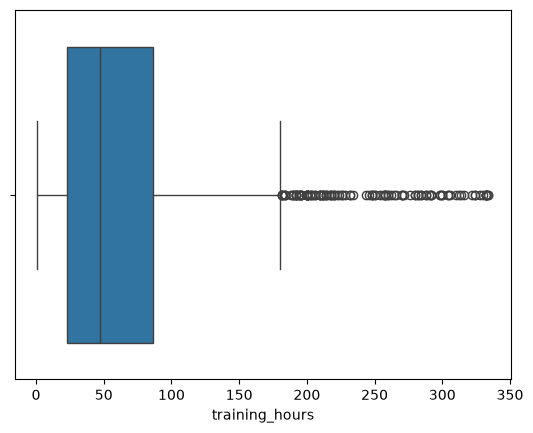

In [32]:
sns.boxplot(x= df['training_hours'])

In [33]:
# finding the IQR
percentile25 = df['training_hours'].quantile(.25)
percentile75 = df['training_hours'].quantile(.75)

In [34]:
percentile25

np.float64(23.0)

In [35]:
percentile75

np.float64(86.0)

In [36]:
IQR = percentile75 - percentile25

In [37]:
IQR

np.float64(63.0)

In [38]:
upper_limit = percentile75 + 1.5*IQR
upper_limit

np.float64(180.5)

In [39]:
lower_limit = percentile75 - 1.5*IQR
lower_limit

np.float64(-8.5)

In [40]:
# Finding out outlier
df[df['training_hours']>upper_limit]

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours
10,10856,city_103,0.920,Male,Has relevent experience,no_enrollment,Masters,Other,>20,NaN,NaN,>4,196
46,6312,city_160,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,270
70,20723,city_11,0.550,Male,Has relevent experience,Full time course,Graduate,STEM,<1,50-99,Pvt Ltd,1,188
71,13539,city_143,0.740,Male,Has relevent experience,no_enrollment,Graduate,STEM,13,<10,Pvt Ltd,2,182
72,3214,city_16,0.910,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,1000-4999,Pvt Ltd,4,282
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1937,181,city_21,0.624,Male,Has relevent experience,no_enrollment,Graduate,STEM,<1,10/49,Early Stage Startup,1,300
1950,21469,city_84,0.698,Male,Has relevent experience,no_enrollment,Graduate,STEM,5,100-500,Pvt Ltd,1,248
1959,32229,city_30,0.698,Male,Has relevent experience,Full time course,Graduate,STEM,5,100-500,Pvt Ltd,1,192
2004,28680,city_160,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,10,10000+,Pvt Ltd,3,194


In [42]:
# Finding out outlier
df[df['training_hours']<lower_limit]

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours


In [43]:
# Trimming --- > 4(lower) ..... 1, upper(25) ..... (50) --- > here 1,50 are outliers --- >
# Lower(4) <---- > upper(25) mid data .

# Capping ---- > 4(Lower) ..... 1 , upper(25) ..... (50) --- > capping Lower point lowest point(1)
# upper point upper point(50) --- > Range expand --- > outliers remove .

In [44]:
# Trimming Outlier  Removing Technique

In [45]:
newdf = df[df['training_hours']<upper_limit]

In [46]:
newdf

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours
0,32403,city_41,0.827,Male,Has relevent experience,Full time course,Graduate,STEM,9,<10,NaN,1,21
1,9858,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,5,NaN,Pvt Ltd,1,98
2,31806,city_21,0.624,Male,No relevent experience,no_enrollment,High School,NaN,<1,NaN,Pvt Ltd,never,15
3,27385,city_13,0.827,Male,Has relevent experience,no_enrollment,Masters,STEM,11,10/49,Pvt Ltd,1,39
4,27724,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,10000+,Pvt Ltd,>4,72
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2124,1289,city_103,0.920,Male,No relevent experience,no_enrollment,Graduate,Humanities,16,NaN,Public Sector,4,15
2125,195,city_136,0.897,Male,Has relevent experience,no_enrollment,Masters,STEM,18,NaN,NaN,2,30
2126,31762,city_100,0.887,Male,No relevent experience,no_enrollment,Primary School,NaN,3,NaN,Pvt Ltd,never,18
2127,7873,city_102,0.804,Male,Has relevent experience,Full time course,High School,NaN,7,100-500,Public Sector,1,84


In [47]:
# comaprison

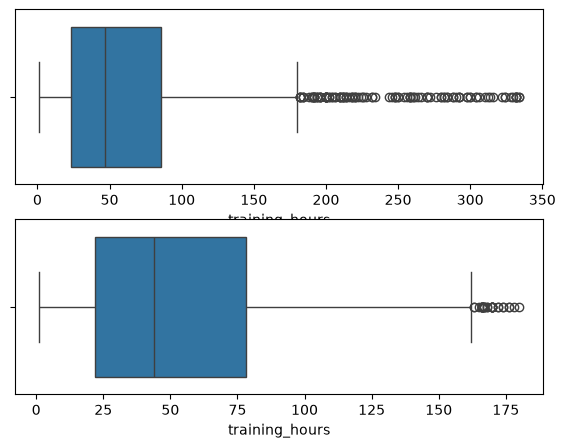

In [48]:
plt.figure(figsize = (15,5))

plt.subplot(222)
sns. boxplot(x = df['training_hours' ])

plt.subplot(224)
sns.boxplot(x = newdf['training_hours'])
plt.show()

# 2. Capping  (outlier removing techinue)

In [49]:
#

In [53]:
new_df_cap = df.copy()

In [54]:
# min = 5 , max 15

# min 4, 3, 1
# max = 20, 30, 50

# updated_min_value = 1
# updated_max_value = 50

In [55]:
new_df_cap['training_hours'] = np.where(
    new_df_cap['training_hours'] > upper_limit,
    upper_limit,

    np.where(
        new_df_cap['training_hours'] < lower_limit,
        lower_limit,
        new_df_cap['training_hours']
    )
)

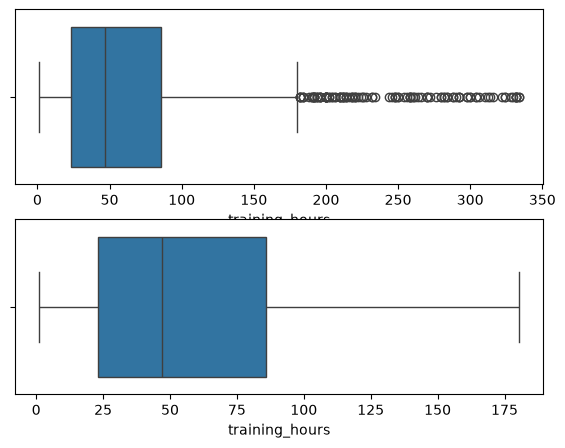

In [56]:
plt.figure(figsize = (15,5))

plt.subplot(222)
sns. boxplot(x = df['training_hours' ])

plt.subplot(224)
sns.boxplot(x = new_df_cap['training_hours'])
plt.show()